In [1]:
!pip install snntorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 7.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

PT_DATASET = "/content/drive/MyDrive/DVS128_PT"

Mounted at /content/drive


In [3]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

import snntorch as snn
from snntorch import surrogate

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [5]:
NUM_CLASSES = 11

beta = 0.95

spike_grad = surrogate.fast_sigmoid()

In [6]:
class DVSGestureSNN(nn.Module):

    def __init__(self):

        super().__init__()

        # ---------- Feature Extraction ----------

        self.conv1 = nn.Conv2d(
            2,
            16,
            kernel_size=3,
            padding=1
        )

        self.pool1 = nn.MaxPool2d(2)

        self.lif1 = snn.Leaky(
            beta=beta,
            spike_grad=spike_grad
        )

        self.conv2 = nn.Conv2d(
            16,
            32,
            kernel_size=3,
            padding=1
        )

        self.pool2 = nn.MaxPool2d(2)

        self.lif2 = snn.Leaky(
            beta=beta,
            spike_grad=spike_grad
        )

        self.conv3 = nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        )

        self.pool3 = nn.MaxPool2d(2)

        self.lif3 = snn.Leaky(
            beta=beta,
            spike_grad=spike_grad
        )

        # ---------- Classifier ----------

        self.fc = nn.Linear(
            64 * 16 * 16,
            NUM_CLASSES
        )

    def forward(self, x):

        """
        x shape:
        (batch, 30, 2, 128, 128)
        """

        batch_size = x.size(0)

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spike_sum = torch.zeros(
            batch_size,
            NUM_CLASSES,
            device=x.device
        )

        # Process each time bin
        for t in range(x.size(1)):

            out = x[:, t]

            out = self.conv1(out)
            out = self.pool1(out)
            spk1, mem1 = self.lif1(out, mem1)

            out = self.conv2(spk1)
            out = self.pool2(out)
            spk2, mem2 = self.lif2(out, mem2)

            out = self.conv3(spk2)
            out = self.pool3(out)
            spk3, mem3 = self.lif3(out, mem3)

            out = out.reshape(batch_size, -1)

            out = self.fc(out)

            spike_sum += out

        return spike_sum / x.size(1)

In [7]:
class PTGestureDataset(Dataset):

    def __init__(self, metadata):

        self.metadata = metadata

    def __len__(self):

        return len(self.metadata)

    def __getitem__(self, index):

        sample = self.metadata.iloc[index]

        voxel = torch.load(
            os.path.join(
                PT_DATASET,
                sample["file"]
            )
        )

        # Convert int8 back to float32
        voxel = voxel.float() / 127.0

        label = torch.tensor(
            sample["label"],
            dtype=torch.long
        )

        return voxel, label

In [8]:
metadata = pd.read_csv(
    os.path.join(
        PT_DATASET,
        "metadata.csv"
    )
)

test_metadata = metadata[
    metadata["split"] == "test"
].reset_index(drop=True)

print(len(test_metadata))

288


In [9]:
test_dataset = PTGestureDataset(test_metadata)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [10]:
MODEL_PATH = "/content/drive/MyDrive/DVS128_PT/dvs_snn_model.pth"
model = DVSGestureSNN().to(device)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [11]:
print(model.conv1.weight.mean().item())
print(model.conv1.weight.std().item())

0.00710258400067687
0.15400904417037964


In [12]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("Done!")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Done!


In [13]:
acc = accuracy_score(
    all_labels,
    all_preds
)

print(acc)

0.6736111111111112


In [14]:
print(
    classification_report(
        all_labels,
        all_preds
    )
)

              precision    recall  f1-score   support

           0       0.71      0.71      0.71        24
           1       1.00      0.79      0.88        24
           2       0.88      0.62      0.73        24
           3       0.55      0.46      0.50        24
           4       0.64      0.67      0.65        24
           5       0.75      0.25      0.38        24
           6       0.45      0.83      0.59        24
           7       0.97      0.67      0.79        48
           8       0.57      0.67      0.62        24
           9       0.65      0.92      0.76        24
          10       0.56      0.83      0.67        24

    accuracy                           0.67       288
   macro avg       0.70      0.67      0.66       288
weighted avg       0.72      0.67      0.67       288



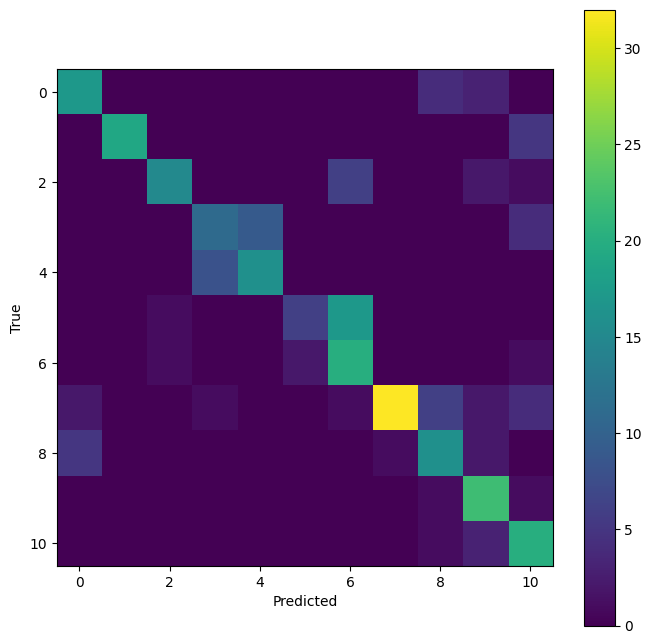

In [15]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,8))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

In [16]:
MODEL_PATH = "/content/drive/MyDrive/DVS128_PT/dvs_snn_model.pth"

state_dict = torch.load(MODEL_PATH, map_location=device)

print(type(state_dict))
print(len(state_dict))
print(list(state_dict.keys())[:5])

<class 'collections.OrderedDict'>
20
['conv1.weight', 'conv1.bias', 'lif1.threshold', 'lif1.graded_spikes_factor', 'lif1.reset_mechanism_val']


In [1]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]

train_loss = [1.5351, 0.8459, 0.6999, 0.7030, 0.5927]
test_loss  = [0.9816, 0.9015, 0.9808, 1.0199, 1.0504]

train_acc = [43.54, 65.90, 71.43, 71.26, 75.09]
test_acc  = [59.03, 67.01, 63.19, 66.67, 67.36]

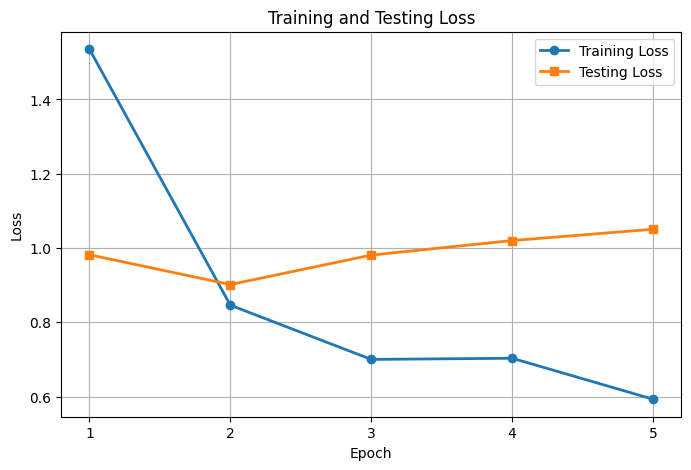

In [2]:
plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss, marker='o', linewidth=2, label='Training Loss')
plt.plot(epochs, test_loss, marker='s', linewidth=2, label='Testing Loss')

plt.title("Training and Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True)
plt.legend()

plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

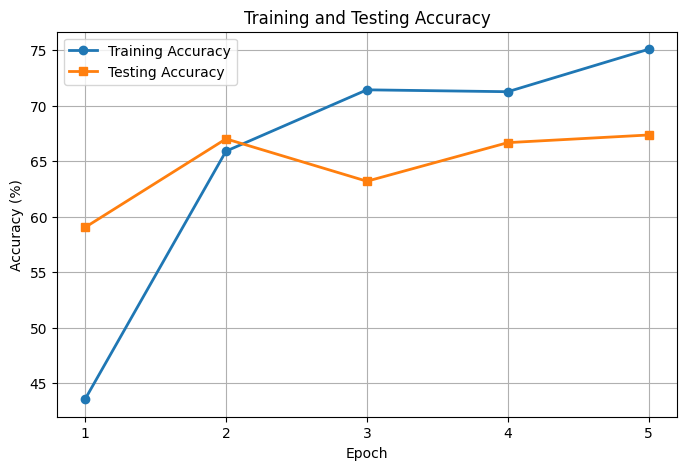

In [3]:
plt.figure(figsize=(8,5))

plt.plot(epochs, train_acc, marker='o', linewidth=2, label='Training Accuracy')
plt.plot(epochs, test_acc, marker='s', linewidth=2, label='Testing Accuracy')

plt.title("Training and Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs)
plt.grid(True)
plt.legend()

plt.savefig("accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
from google.colab import files

files.download("loss_curve.png")
files.download("accuracy_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>